<a href="https://colab.research.google.com/github/ShauryaPrakashVerma/Python_for_AI/blob/main/Decorators_and_Namespaces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Namespace
- A namespace is essentially a mapping between names and objects, and Python resolves names using the LEGB rule
- Local → Enclosing → Global → Built-in.

- there are 4 types of namespaces:
  - Built in namespace
  - Global namespace
  - Enclosing namespace
  - Local namespaces

### Scope --> textual region of the program where a namespace is directly accessible

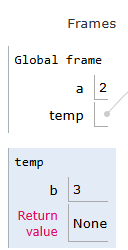

In [1]:
# local and global
# global var
a = 2

def temp():
  # local var
  b = 3
  print(b)

temp()
print(a)

3
2


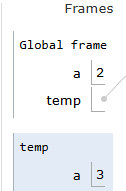

In [2]:
# local and global --> same name
# here both variables name are same but both exist in completely different namespaces, so there is no ambiguity

a = 2

def temp():
  # local var
  a = 3
  print(a)

temp()
print(a)

3
2


In [3]:
# local and global --> local does not have but global has
a = 2

def temp():
  # local var
  print(a)

temp()
print(a)


2
2


In [4]:
# local and global -> editing global

a = 2

def temp():
  # local var
  a += 1
  print(a)

temp()
print(a)

UnboundLocalError: cannot access local variable 'a' where it is not associated with a value

In [6]:
# global keyword used to access the global scope variable
# not a good programming practice

a = 2

def temp():
  # local var
  global a
  a += 1
  print(a)

temp()
print(a)

3
3


In [7]:
# local and global -> global created inside local
# this will create a global variable from a local namepace

def temp():
  # local var
  global a
  a = 1
  print(a)

temp()
print(a)

1
1


In [8]:
# local and global -> function parameter is local
def temp(z):
  # local var
  print(z)

a = 5
temp(5)
print(a)
print(z)


# here z is a local variable or a global variable?
# ans: z --> local variable

5
5


NameError: name 'z' is not defined

In [10]:
a = 2

def temp():
  # local var
  a = 0
  global a
  a += 1
  print(a)

temp()
print(a)

SyntaxError: name 'a' is assigned to before global declaration (3677612793.py, line 6)

In [11]:
# built in scope

import builtins

print(dir(builtins))

['ArithmeticError', 'AssertionError', 'AttributeError', 'BaseException', 'BaseExceptionGroup', 'BlockingIOError', 'BrokenPipeError', 'BufferError', 'BytesWarning', 'ChildProcessError', 'ConnectionAbortedError', 'ConnectionError', 'ConnectionRefusedError', 'ConnectionResetError', 'DeprecationWarning', 'EOFError', 'Ellipsis', 'EncodingWarning', 'EnvironmentError', 'Exception', 'ExceptionGroup', 'False', 'FileExistsError', 'FileNotFoundError', 'FloatingPointError', 'FutureWarning', 'GeneratorExit', 'IOError', 'ImportError', 'ImportWarning', 'IndentationError', 'IndexError', 'InterruptedError', 'IsADirectoryError', 'KeyError', 'KeyboardInterrupt', 'LookupError', 'MemoryError', 'ModuleNotFoundError', 'NameError', 'None', 'NotADirectoryError', 'NotImplemented', 'NotImplementedError', 'OSError', 'OverflowError', 'PendingDeprecationWarning', 'PermissionError', 'ProcessLookupError', 'RecursionError', 'ReferenceError', 'ResourceWarning', 'RuntimeError', 'RuntimeWarning', 'StopAsyncIteration', 'S

In [18]:
# renaming built-ins
# here the max in built in scope (originally used to retrieve the max element of the list), is redesigned by writing it in the global scope.
# so according to the LEGB rule global scope is first accessed before the built in scope.
# so here the max function overwrites the max function in the built in scope

# here the first max will work since the first max accessess the built-in max(since at this time max in global scope has not been created yet)
# the second max will not work, since it will access the global scope max()

# visualize through python tutor

L = [1,2,3]
print(max(L))
def max():
  print('hello')

print(max(L))

TypeError: max() takes 0 positional arguments but 1 was given

In [19]:
# enclosing scope  (non local)
def outer():
  def inner():
    print("inner fxn")
  inner()
  print("outer function")

outer()
print("main program")

inner fxn
outer function
main program


In [20]:
# nonlocal keyword  --> we can change the nonlocal variable from the local scope (not a good programming method)
def outer():
  a = 1
  def inner():
    nonlocal a
    a += 1
    print('inner',a)
  inner()
  print('outer',a)


outer()
print('main program')

inner 2
outer 2
main program


In [ ]:
# functions, if else etc. dont create a seperate namespace. Their namespace is same as the namespace of the function

### Decorators

A decorator in python is a function that receives another function as input and adds some functionality(decoration) to and it and returns it.

This can happen only because python functions are 1st class citizens.

There are 2 types of decorators available in python
- `Built in decorators` like `@staticmethod`, `@classmethod`, `@abstractmethod` and `@property` etc
- `User defined decorators` that we programmers can create according to our needs

In [ ]:
# 1st class citizens
# In Python, functions are first-class citizens (or first-class objects).
# This means that functions are treated like any other object — you can:

# Assign them to variables
# Pass them as arguments to other functions
# Return them from other functions
# Store them in data structures (lists, dictionaries, etc.)

In [21]:
# Python are 1st class function

def modify(func,num):
  return func(num)

def square(num):
  return num**2

modify(square,2)

4

In [27]:
def my_decorator(func):
  def wrapper():
    print("---------------")
    func()
    print("---------------")
  return wrapper

def func():
  print("Hello")

a = my_decorator(func)
a()

---------------
Hello
---------------


In [28]:
# shortform of using the decorator

def my_decorator(func):
  def wrapper():
    print("---------------")
    func()
    print("---------------")
  return wrapper

@my_decorator
def func():
  print("Hello")

func()

---------------
Hello
---------------


In [34]:
import time

# this code will not work if the fucntions have any parameters

def timer(func):
  def wrapper():
    start = time.time()
    func()
    end = time.time()
    print("Time taken by ", func.__name__, " is ", end - start)
  return wrapper

@timer
def calculate_square_4():
  for i in range(4):
    print(i**2)

@timer
def calculate_square_10():
  for i in range(10):
    print(i**2)

calculate_square_4()
calculate_square_10()



0
1
4
9
Time taken by  calculate_square_4  is  4.002033472061157
0
1
4
9
16
25
36
49
64
81
Time taken by  calculate_square_10  is  4.506111145019531e-05


In [38]:
# anything meaningful?
import time

def timer(func):
  def wrapper(*args):
    start = time.time()
    func(*args)
    print('time taken by',func.__name__,time.time()-start,'secs')
  return wrapper

@my_decorator
def hello():
  print('hello world')
  time.sleep(2)

@timer
def square(num):
  time.sleep(1)
  print(num**2)

@timer
def power(a,b):
  print(a**b)

hello()
square(2)
power(2,3)



---------------
hello world
---------------
4
time taken by square 1.000234603881836 secs
8
time taken by power 1.2874603271484375e-05 secs


In [47]:
# custom decorator that checks the data type of the input of the function
# decorator with an input

# something like this:

# @checkdt(int)
# def square(num):
#   print(num**2)

def sanity_check(data_type):
  def outer_wrapper(func):
    def inner_wrapper(*args):
      if type(*args) == data_type:
        func(*args)
      else:
        print("Chal Hatt......")
    return inner_wrapper
  return outer_wrapper

@sanity_check(int)
def square(num):
  print(num**2)

square("hehe")


Chal Hatt......


In [48]:
square(3)

9
